Here we will implement DQN 

In [1]:
import sys
sys.path.append('..')
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random
import numpy as np
import random
from tqdm import trange
import matplotlib as plt
import torch.optim as optim
import gymnasium as gym
from gymnasium.vector import SyncVectorEnv
import matplotlib.pyplot as plt
from burauEnv import BurauEnv
mod = 2
obs = 32

In [3]:


class DQNBurau(nn.Module):
    def __init__(self,obs, hidden_dim = 128):
        super(DQNBurau, self).__init__()
        self.fc1 = nn.Linear(obs, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, 4)  

    def forward(self, x):
        if isinstance(x, np.ndarray):
            x = torch.tensor(x, dtype=torch.float32)
        if len(x.shape) == 1:
            x = x.unsqueeze(0)  # make batch of 1
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc4(x)  # raw Q-values for each action

class ReplayBuffer:
    def __init__(self, capacity, device="cpu"):
        """
        capacity: maximum number of transitions to store
        device:   torch device for all tensors ("cpu" or "cuda")
        """
        self.buffer = deque(maxlen=capacity)
        self.device = device

    def push(self, state, action, reward, next_state, done):
        """
        state, next_state: array‐like or tensor of shape (obs_dim,)
        action:            scalar or array‐like
        reward:            scalar
        done:              bool or 0/1
        """
        # convert each component to a tensor on self.device
        s  = torch.as_tensor(state,      dtype=torch.float32, device=self.device)
        a  = torch.as_tensor(action,     dtype=torch.int64,   device=self.device)
        r  = torch.as_tensor(reward,     dtype=torch.float32, device=self.device)
        ns = torch.as_tensor(next_state, dtype=torch.float32, device=self.device)
        d  = torch.as_tensor(done,       dtype=torch.bool,    device=self.device)

        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions, returns a tuple of:
         (states, actions, rewards, next_states, dones)
        where each is a tensor of shape (batch_size, ...).
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.stack(states),       # shape: [B, obs_dim]
            torch.stack(actions),      # shape: [B] or [B, *action_shape]
            torch.stack(rewards),      # shape: [B]
            torch.stack(next_states),  # shape: [B, obs_dim]
            torch.stack(dones),        # shape: [B]
        )

    def __len__(self):
        return len(self.buffer)

It is training routine

In [28]:



# ── Hyperparameters ────────────────────────────────────────────────────────────
MOD               = 2
OBS_SPACE         = 34
NUM_ENVS          = 8
TOTAL_STEPS       = 100000
BATCH_SIZE        = 500
GAMMA             = 0.99
EPS_START         = 1.0
EPS_END           = 0.1
EPS_DECAY         = 10000   # steps
TARGET_UPDATE_F   = 1000    # steps
REPLAY_CAPACITY   = 100000
LR                = 0.003

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ── Make a vector of BurauEnvs ─────────────────────────────────────────────────
def make_env(mod=MOD, obs=OBS_SPACE):
    def _init():
        return BurauEnv(mod=mod, obs=obs)
    return _init

venv = SyncVectorEnv([make_env() for _ in range(NUM_ENVS)])


# ── Networks, optimizer, buffer ────────────────────────────────────────────────
q_net      = DQNBurau(OBS_SPACE).to(device)
target_net = DQNBurau(OBS_SPACE).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer      = optim.Adam(q_net.parameters(), lr=LR)
replay_buffer  = ReplayBuffer(REPLAY_CAPACITY)


# ── Action selection ────────────────────────────────────────────────────────────
def select_actions(batch_states, epsilon, legal_actions):
    """
    batch_states: np.ndarray of shape [NUM_ENVS, obs_dim]
    returns np.array of shape [NUM_ENVS] with ints in [0, action_space-1]
    """
    actions = []
    for s in batch_states:
        if random.random() < epsilon:
            actions.append(random.choice(legal_actions.pop(0)))
        else:
            with torch.no_grad():
                t = torch.from_numpy(s).float().to(device).unsqueeze(0)
                qvals = q_net(t)                                # [1, n_actions]
                actions.append( int(qvals.argmax(dim=1).item()) )          
    return np.array(actions, dtype=np.int32)



loss_history = []
best_power_range_history = []
best_power_range = 100


# ── Main training loop ─────────────────────────────────────────────────────────
obs_batch, _ = venv.reset(seed=0)   # obs_batch: [NUM_ENVS, obs_dim]
epsilon = EPS_START
step_count = 0

for step in trange(TOTAL_STEPS):
    # 1) choose a batch of actions
    legal_actions = []
    for env in venv.envs:
        legal_actions.append(env.legal_actions())
    actions = select_actions(obs_batch, epsilon, legal_actions)
    # 2) step all envs in one go
    next_obs, rewards, terms, truncs, infos = venv.step(actions)
    dones = np.logical_or(terms, truncs)



    # 3) store each transition
    terminal_obs = infos.get("terminal_observation", None)
    for i in range(NUM_ENVS):
        obs_i   = obs_batch[i]
        act_i   = int(actions[i])
        rew_i   = float(rewards[i])
        done_i  = bool(dones[i])

        if done_i and terminal_obs is not None:
            # the true final state before reset
            ns_i = terminal_obs[i]
        else:
            # the next state (or first obs of the next episode)
            ns_i = next_obs[i]

        replay_buffer.push(obs_i, act_i, rew_i, ns_i, done_i)

    obs_batch = next_obs
    step_count += 1
    epsilon = max(EPS_END, EPS_START - step_count / EPS_DECAY)
    for _ in range(OBS_SPACE):
        # 4) learning step
        if len(replay_buffer) >= BATCH_SIZE:
            states, acts, rews, next_states, dones_b = replay_buffer.sample(BATCH_SIZE)
            
            states      = states.to(device)
            acts        = acts.to(device).unsqueeze(1)
            rews        = rews.to(device)
            next_states = next_states.to(device)
            dones_b     = dones_b.to(device)

            # Q(s,a)
            q_values = q_net(states).gather(1, acts).squeeze(-1)  

            # target: r + γ·max Q_target(s',·) · (1−done)
            with torch.no_grad():
                next_q     = target_net(next_states)              
                max_next_q = next_q.max(dim=1).values             
                target_q   = rews + GAMMA * max_next_q * (~dones_b)

            loss = F.mse_loss(q_values, target_q)
            
            loss_history.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



    if step % 100 == 0:
        env = BurauEnv(2,OBS_SPACE)
        state, _ = env.reset()
        valid = True
        done = False
        while not done:
            with torch.no_grad():
                q_vals = q_net(torch.tensor(state, dtype=torch.float32).to(device))
                action = torch.argmax(q_vals).item()
                state, reward, term, trunc, _ = env.step(action)
                if reward < -10:
                    valid = False
                done = term or trunc
        if(valid):
            best_power_range_history.append(env.power_range)
        if(env.power_range < best_power_range and valid):
            
            best_power_range = env.power_range
            torch.save(q_net.state_dict(), "best_model.pth")
            print(f"Best power range:{best_power_range}")
        

    # 5) periodically sync target network
    if step_count % TARGET_UPDATE_F == 0:
        target_net.load_state_dict(q_net.state_dict())



  0%|          | 63/100000 [00:00<05:16, 315.26it/s]

Best power range:34


  1%|          | 703/100000 [00:28<1:06:48, 24.77it/s]


KeyboardInterrupt: 

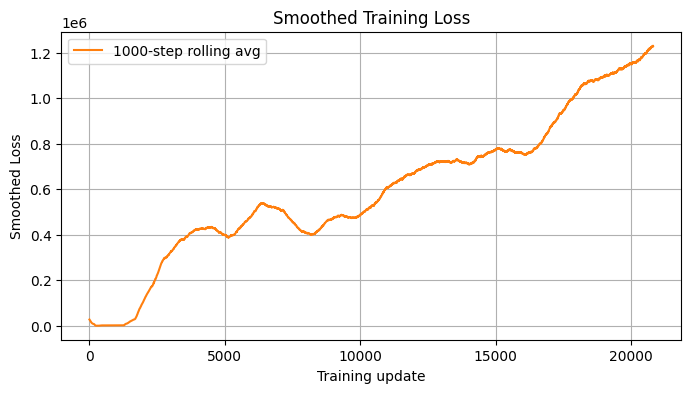

In [29]:


window = 1000
smoothed = np.convolve(
    loss_history, 
    np.ones(window)/window, 
    mode="valid"
)

plt.figure(figsize=(8,4))
plt.plot(smoothed, color="C1", label=f"{window}-step rolling avg")
plt.xlabel("Training update")
plt.ylabel("Smoothed Loss")
plt.title("Smoothed Training Loss")
plt.legend()
plt.grid(True)
plt.show()

/var/folders/xq/v0np8t7d36x0t1jk8jj9f48c0000gn/T/ipykernel_37065/3121057122.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


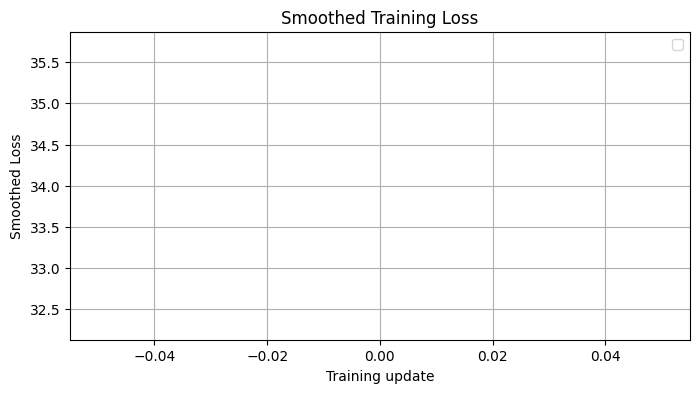

In [30]:


plt.figure(figsize=(8,4))
plt.plot(best_power_range_history, color="C1")
plt.xlabel("Training update")
plt.ylabel("Smoothed Loss")
plt.title("Smoothed Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [3]:
env = BurauEnv(2,32)
q_net = DQNBurau(32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_net.load_state_dict(torch.load('best_model.pth',weights_only=True))
state, _ = env.reset()
done = False
while not done:
    with torch.no_grad():
        q_vals = q_net(torch.tensor(state, dtype=torch.float32).to(device))
        action = torch.argmax(q_vals).item()
        state, _, term, trunc, _ = env.step(action)
        done = term or trunc
env.render()
env.power_range

[Turn 32] word = ABAABABABAABABABAABABABABAABABAA


7

In [6]:



# ── Hyperparameters ────────────────────────────────────────────────────────────
MOD               = 2
OBS_SPACE         = 32
NUM_ENVS          = 32
TOTAL_STEPS       = 35000
BATCH_SIZE        = 64
GAMMA             = 0.99
EPS_START         = 1.0
EPS_END           = 0.1
EPS_DECAY         = 10000   # steps
TARGET_UPDATE_F   = 1000    # steps
REPLAY_CAPACITY   = 100000
LR                = 0.003

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ── Make a vector of BurauEnvs ─────────────────────────────────────────────────
def make_env(mod=MOD, obs=OBS_SPACE):
    def _init():
        return BurauEnv(mod=mod, obs=obs)
    return _init

venv = SyncVectorEnv([make_env() for _ in range(NUM_ENVS)])


# ── Networks, optimizer, buffer ────────────────────────────────────────────────
q_net      = DQNBurau(OBS_SPACE).to(device)
target_net = DQNBurau(OBS_SPACE).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer      = optim.Adam(q_net.parameters(), lr=LR)
replay_buffer  = ReplayBuffer(REPLAY_CAPACITY)


# ── Action selection ────────────────────────────────────────────────────────────
def select_actions(batch_states, epsilon):
    """
    batch_states: np.ndarray of shape [NUM_ENVS, obs_dim]
    returns np.array of shape [NUM_ENVS] with ints in [0, action_space-1]
    """
    actions = []
    for s in batch_states:
        if random.random() < epsilon:
            actions.append( random.randrange(4))
        else:
            with torch.no_grad():
                t = torch.from_numpy(s).float().to(device).unsqueeze(0)
                qvals = q_net(t)                                # [1, n_actions]
                actions.append( int(qvals.argmax(dim=1).item()) )
    return np.array(actions, dtype=np.int32)



loss_history = []
best_power_range_history = []
best_power_range = 100


# ── Main training loop ─────────────────────────────────────────────────────────
obs_batch, _ = venv.reset(seed=0)   # obs_batch: [NUM_ENVS, obs_dim]
epsilon = EPS_START
step_count = 0

for step in trange(TOTAL_STEPS):
    # 1) choose a batch of actions
    actions = select_actions(obs_batch, epsilon)
    
    # 2) step all envs in one go
    next_obs, rewards, terms, truncs, infos = venv.step(actions)
    dones = np.logical_or(terms, truncs)

    # 3) store each transition
    terminal_obs = infos.get("terminal_observation", None)
    for i in range(NUM_ENVS):
        obs_i   = obs_batch[i]
        act_i   = int(actions[i])
        rew_i   = float(rewards[i])
        done_i  = bool(dones[i])

        if done_i and terminal_obs is not None:
            # the true final state before reset
            ns_i = terminal_obs[i]
        else:
            # the next state (or first obs of the next episode)
            ns_i = next_obs[i]

        replay_buffer.push(obs_i, act_i, rew_i, ns_i, done_i)

    obs_batch = next_obs
    step_count += 1
    epsilon = max(EPS_END, EPS_START - step_count / EPS_DECAY)

    # 4) learning step
    if len(replay_buffer) >= BATCH_SIZE:
        states, acts, rews, next_states, dones_b = replay_buffer.sample(BATCH_SIZE)
        
        states      = states.to(device)
        acts        = acts.to(device).unsqueeze(1)
        rews        = rews.to(device)
        next_states = next_states.to(device)
        dones_b     = dones_b.to(device)

        # Q(s,a)
        q_values = q_net(states).gather(1, acts).squeeze(-1)  

        # target: r + γ·max Q_target(s',·) · (1−done)
        with torch.no_grad():
            next_q     = target_net(next_states)              
            max_next_q = next_q.max(dim=1).values             
            target_q   = rews + GAMMA * max_next_q * (~dones_b)

        loss = F.mse_loss(q_values, target_q)
        
        loss_history.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()



        if step % 1 == 0:
            env = BurauEnv(2,OBS_SPACE)
            state, _ = env.reset()
            valid = True
            done = False
            while not done:
                with torch.no_grad():
                    q_vals = q_net(torch.tensor(state, dtype=torch.float32).to(device))
                    action = torch.argmax(q_vals).item()
                    state, reward, term, trunc, _ = env.step(action)
                    if reward < -10:
                        valid = False
                    done = term or trunc
            if(valid):
                best_power_range_history.append(env.power_range)
            if(env.power_range < best_power_range and valid):
                
                best_power_range = env.power_range
                torch.save(q_net.state_dict(), "best_model.pth")
                print(f"Best power range:{best_power_range}")
            

    # 5) periodically sync target network
    if step_count % TARGET_UPDATE_F == 0:
        target_net.load_state_dict(q_net.state_dict())



  0%|          | 24/35000 [00:00<05:01, 115.90it/s]

Best power range:32


  1%|          | 377/35000 [00:03<04:49, 119.72it/s]

Best power range:31


  5%|▌         | 1785/35000 [00:15<04:36, 120.14it/s]

...

 67%|██████▋   | 23512/35000 [06:15<03:25, 55.83it/s]

Best power range:10


 91%|█████████ | 31858/35000 [08:34<00:49, 63.59it/s]

Best power range:9


100%|██████████| 35000/35000 [09:40<00:00, 60.25it/s]


/var/folders/xq/v0np8t7d36x0t1jk8jj9f48c0000gn/T/ipykernel_92831/399901770.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


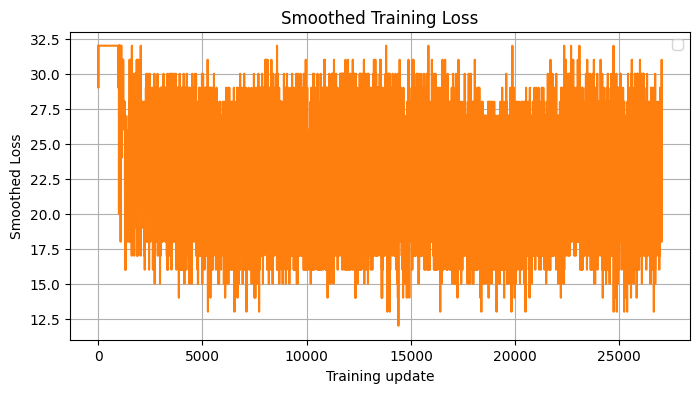

In [5]:
plt.figure(figsize=(8,4))
plt.plot(best_power_range_history, color="C1")
plt.xlabel("Training update")
plt.ylabel("Smoothed Loss")
plt.title("Smoothed Training Loss")
plt.legend()
plt.grid(True)
plt.show()

Dima Algorithm:

In [25]:


def train_fc(
        modulo,
        max_steps,
        num_episodes=2000000,
        batch_size=64,
        gamma=0.99,
        lr=3e-4,
        buffer_capacity=100000,
        target_update_freq=1000,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=10000      # slower decay for more exploration
):

    # Reproducibility
    torch.manual_seed(43)
    np.random.seed(43)
    random.seed(43)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    epsilon = epsilon_start

    # Networks and optimizer
    # policy_net = BurauDQN(input_dim=max_steps, hidden_dim=512).to(device)
    # target_net = BurauDQN(input_dim=max_steps, hidden_dim=512).to(device)

    q_net = DQNBurau(max_steps).to(device)
    target_net = DQNBurau(max_steps).to(device)

    target_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=lr)

    replay_buffer = ReplayBuffer(buffer_capacity, device)
    env = BurauEnv(modulo, max_steps)

    loss_history = []
    best_power_range_history = []
    best_power_range = 100

    for step in trange(1, num_episodes + 1):
        state, _ = env.reset()

        for t in range(max_steps):
            # 1) Select action (ε-greedy)
            if random.random() < epsilon:
                if step < 1000:
                    action = random.randrange(4)
                else:
                    action = random.choice(env.legal_actions())
            else:
                with torch.no_grad():
                    inp    = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    qvals = q_net(inp).squeeze(0)
                action = qvals.argmax().item()

            # 2) Step environment
            next_state, reward, term, trunc, info = env.step(action)
            done = np.logical_or(term, trunc)
            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            if done:
                state, _ = env.reset()

            # 5) Sample & train
            if len(replay_buffer) >= batch_size:
                states, acts, rews, next_states, dones_b = replay_buffer.sample(batch_size)
                
                states      = states.to(device)
                acts        = acts.to(device).unsqueeze(1)
                rews        = rews.to(device)
                next_states = next_states.to(device)
                dones_b     = dones_b.to(device)

                # Q(s,a)
                q_values = q_net(states).gather(1, acts).squeeze(-1)  

                # target: r + γ·max Q_target(s',·) · (1−done)
                with torch.no_grad():
                    next_q     = target_net(next_states)              
                    max_next_q = next_q.max(dim=1).values             
                    target_q   = rews + gamma * max_next_q * (~dones_b)

                loss = F.mse_loss(q_values, target_q)
                loss_history.append(loss.item())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
        if step % 1000 == 0:
                
                env_test = BurauEnv(modulo,max_steps)
                state, _ = env.reset()
                valid = True
                done = False
                while not done:
                    with torch.no_grad():
                        q_vals = q_net(torch.tensor(state, dtype=torch.float32).to(device))
                        action = torch.argmax(q_vals).item()
                        state, reward, term, trunc, _ = env_test.step(action)
                        
                        if reward < -10:
                            valid = False
                            
                        done = term or trunc
                env_test.render()
                if(valid):
                    best_power_range_history.append(env_test.power_range)
                    
                if(env_test.power_range < best_power_range and valid):
                    
                    best_power_range = env_test.power_range
                    print(f"Best power range:{best_power_range}")


        # 6) Update target network periodically
        if step % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())
        epsilon = max(epsilon_min, epsilon_start - step / epsilon_decay)
            

        

train_fc(2,34)

  0%|          | 0/2000000 [00:00<?, ?it/s]/var/folders/xq/v0np8t7d36x0t1jk8jj9f48c0000gn/T/ipykernel_46029/639870151.py:38: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  d  = torch.as_tensor(done,       dtype=torch.bool,    device=self.device)
  0%|          | 301/2000000 [00:11<20:39:42, 26.88it/s]


KeyboardInterrupt: 

In [49]:
import copy
import math
import torch
import torch.nn.functional as F
import numpy as np
import random
from collections import deque

sys.path.append('../../../scripts')
from free_scripts import largest_power_range


def train_fc(
        modulo,
        max_steps,
        num_episodes=2000000,
        batch_size=64,
        gamma=0.99,
        lr=3e-4,
        buffer_capacity=100000,
        target_update_freq=1000,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.9999       # slower decay for more exploration
):

    # Reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    epsilon = epsilon_start

    # Networks and optimizer
    # policy_net = BurauDQN(input_dim=max_steps, hidden_dim=512).to(device)
    # target_net = BurauDQN(input_dim=max_steps, hidden_dim=512).to(device)

    policy_net = DQNBurau(max_steps).to(device)
    target_net = DQNBurau(max_steps).to(device)

    target_net.load_state_dict(policy_net.state_dict())
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)

    replay_buffer = ReplayBuffer(buffer_capacity, device)
    steps_done = 0
    env = BurauEnv(modulo, max_steps)

    # For simple logging
    recent_rewards = deque(maxlen=100)
    recent_losses  = deque(maxlen=100)

    avg_loss_history = []
    win_count = lose_count = timeout_count = 0


    for episode in range(1, num_episodes + 1):
        state, _        = env.reset()
        total_reward = 0.0
        loss_sum     = 0.0
        loss_count   = 0
        eval_info    = ""
        prev_max = env.power_range

        for t in range(max_steps):
            done = False
            if done:
                state, _ = env.reset()
            # 1) Select action (ε-greedy)
            if random.random() < epsilon:
                action = random.choice(env.legal_actions())
            else:
                with torch.no_grad():
                    inp    = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    qvals = policy_net(inp).squeeze(0)
                action = qvals.argmax().item() 

            # 2) Step environment
            next_state, reward, term, trunc, info = env.step(action)
            done = np.logical_or(term, trunc)

            total_reward += reward

            # 4) Store transition
            
            replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            steps_done += 1
            

            # 5) Sample & train
            if len(replay_buffer) >= batch_size:
                s_b, a_b, r_b, ns_b, d_b = replay_buffer.sample(batch_size)
                q_p = policy_net(s_b).gather(1, a_b.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    q_n = target_net(ns_b).max(1)[0]
                    q_t = r_b + gamma * q_n * (~d_b)
                loss = F.mse_loss(q_p, q_t)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                loss_sum   += loss.item()
                loss_count += 1

            # 6) Update target network periodically
            if steps_done % target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())


            if loss_count:
                avg_loss = (loss_sum / loss_count)
                avg_loss_history.append(avg_loss)

        # Record final word and range after episode
        final_word  = env.word
        final_range = env.power_range

        # Periodic evaluation (greedy policy) every 1000 episodes
        if episode % 100 == 0:
            eval_env = BurauEnv(modulo, max_steps)
            s_eval, _   = eval_env.reset()
            for _ in range(max_steps):
                with torch.no_grad():
                
                    inp_eval = torch.tensor(s_eval, dtype=torch.float32, device=device).unsqueeze(0)
                    qvals_eval = policy_net(inp_eval).squeeze(0)
                    
                a_eval = qvals_eval.argmax().item() 
                s_eval, _, term, trunc, _ = eval_env.step(a_eval)
                if term or trunc:
                    break
            eval_word  = eval_env.word
            eval_range = eval_env.power_range
            eval_info  = f", EvalWord={eval_word}, EvalRange={eval_range}"

        # End-of-episode logging and epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        recent_rewards.append(total_reward)
        recent_losses.append((loss_sum / loss_count) if loss_count else 0.0)

        if episode % 100 == 0:
            avg_r = sum(recent_rewards) / len(recent_rewards)
            avg_l = sum(recent_losses) / len(recent_losses)
            total = win_count + lose_count + timeout_count
            win_pct     = win_count / total * 100 if total else 0
            lose_pct    = lose_count / total * 100 if total else 0
            timeout_pct = timeout_count / total * 100 if total else 0
            print(
                f"[Episode {episode:6d}] AvgReward={avg_r:.3f}, AvgLoss={avg_l:.5f}, "
                f"FinalWord={final_word}, MaxPowerRange={final_range}, "
                f"Wins={win_pct:.0f}%, Loses={lose_pct:.0f}%, Timeouts={timeout_pct:.0f}%" + eval_info
            )
            win_count = lose_count = timeout_count = 0


train_fc(2,34)

/var/folders/xq/v0np8t7d36x0t1jk8jj9f48c0000gn/T/ipykernel_46029/639870151.py:38: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  d  = torch.as_tensor(done,       dtype=torch.bool,    device=self.device)


[Episode    100] AvgReward=-25.310, AvgLoss=0.22394, FinalWord=[2 1 1 2 4 2 1 2 2 4 2 1 1 1 3 4 1 1 1 3 4 2 2 1 3 1 3 1 3 1 2 2 2 2], MaxPowerRange=24, Wins=0%, Loses=0%, Timeouts=0%, EvalWord=[4 4 2 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], EvalRange=2
[Episode    200] AvgReward=-35.550, AvgLoss=5.74095, FinalWord=[4 3 3 4 4 3 4 3 3 3 3 4 4 2 2 2 2 1 3 4 3 3 3 3 1 1 3 3 4 2 2 2 2 2], MaxPowerRange=26, Wins=0%, Loses=0%, Timeouts=0%, EvalWord=[4 4 4 4 4 4 2 2 1 1 1 1 1 1 1 1 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], EvalRange=15
[Episode    300] AvgReward=-41.320, AvgLoss=21.68784, FinalWord=[3 3 3 4 2 1 3 2 4 2 2 1 3 3 4 3 3 1 3 4 3 3 1 3 4 4 4 4 2 4 2 1 3 1], MaxPowerRange=24, Wins=0%, Loses=0%, Timeouts=0%, EvalWord=[3 4 4 3 3 3 3 3 4 3 4 4 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], EvalRange=9
[Episode    400] AvgReward=-48.030, AvgLoss=26.91646, FinalWord=[3 1 1 1 2 1 3 1 1 2 4 3 1 1 2 2 4 2 4 4 2 2 2 4 4 3 4 3 4 3 3 3 4 2], MaxPowerRange=28, Wins=0%, Loses=0%

KeyboardInterrupt: 